<a href="https://colab.research.google.com/github/chandiki/Notion-SentimentAnalysis/blob/main/04_Notion_Review_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notion Google Play Review Sentiment Analysis**

## **⚙️ Process Description**

| Step | Process | Description | Method / Tool |
|------|--------|-------------|----------------|
| 1 | Data Loading | Load raw dataset into structured DataFrame for analysis. | pandas |
| 2 | TextBlob Installation | Install and import TextBlob for sentiment scoring. | pip install textblob |
| 3 | Sentiment Scoring | Generate polarity and subjectivity scores from text data. | TextBlob |
| 4 | Sentiment Labeling | Classify text into positive, negative, and neutral categories. | custom function |
| 5 | EDA (Exploratory Data Analysis) | Analyze distribution and patterns in dataset. | pandas, seaborn |
| 6 | Scatter Plot | Visualize polarity vs subjectivity relationship. | seaborn |
| 7 | Most Frequent Words | Identify most common words in dataset. | FreqDist |
| 8 | Word Cloud | Visualize most frequent words in graphical form. | WordCloud |
| 9 | Review Count by Year | Analyze number of reviews per year. | groupby pandas |
| 10 | Distribution of Ratings | Visualize rating distribution across dataset. | countplot seaborn |
| 11 | Sentiment Trend Over Time | Analyze sentiment changes across years. | stacked bar chart |

### **Data Loading**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import pandas as pd
import numpy as np

df_notion_clean = pd.read_csv('/content/drive/MyDrive/Tugas Individu/Dataset/review_notion_clean.csv')
df_notion_clean.head()

,content,score,at,thumbsUpCount,replyContent,final_text,final_tokens
0,"had a payment issue, the SAV solved it quickly.",5,2026-04-29 16:35:03,0,NaN,payment issu solv quickli,"['payment', 'issu', 'solv', 'quickli']"
1,"Using Notion on a high-end phone, but it keeps...",1,2026-04-29 14:15:07,0,NaN,use notion highend phone keep get laggier upda...,"['use', 'notion', 'highend', 'phone', 'keep', ..."
2,"I loved this app, but my documents keep going ...",3,2026-04-29 10:38:49,0,NaN,love app document keep go miss,"['love', 'app', 'document', 'keep', 'go', 'miss']"
3,powerful (All in 1). but new ke liye itna jada...,1,2026-04-29 09:22:59,0,NaN,power new ke hard hai use bad ui ux,"['power', 'new', 'ke', 'hard', 'hai', 'use', '..."
4,Very bad mobile experience. Everything is so s...,1,2026-04-28 20:29:03,0,NaN,bad mobil experi everyth slow hard actual save...,"['bad', 'mobil', 'experi', 'everyth', 'slow', ..."


In [10]:
df_notion_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   content        20758 non-null  object
 1   score          20758 non-null  int64 
 2   at             20758 non-null  object
 3   thumbsUpCount  20758 non-null  int64 
 4   replyContent   161 non-null    object
 5   final_text     20758 non-null  object
 6   final_tokens   20758 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.1+ MB


### **TextBlob Installation & Sentiment Scoring**

In [73]:
from textblob import TextBlob

df_notion_clean['sentiment_polarity'] = df_notion_clean['final_text'].astype(str).apply(
    lambda x: TextBlob(x).polarity
)

df_notion_clean['sentiment_subjectivity'] = df_notion_clean['final_text'].astype(str).apply(
    lambda x: TextBlob(x).subjectivity
)

In [74]:
def label_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

df_notion_clean['sentiment_label'] = df_notion_clean['sentiment_polarity'].apply(label_sentiment)
df_notion_clean[['content', 'final_text', 'sentiment_polarity', 'sentiment_subjectivity']].head(5)

,content,final_text,sentiment_polarity,sentiment_subjectivity
0,"had a payment issue, the SAV solved it quickly.",payment issu solv quickli,0.000000,0.000000
1,"Using Notion on a high-end phone, but it keeps getting laggier after updates. Table selection is difficult, especially for full rows or columns, and copying email addresses adds a “mailto:” prefix. Basic features feel broken, making the app frustrating to use. Moving away because of this. I'm going back to google ecosystem.",use notion highend phone keep get laggier updat tabl select difficult especi full row column copi email address add basic featur feel broken make app frustrat use move away im go back googl ecosystem,-0.110000,0.415000
2,"I loved this app, but my documents keep going missing",love app document keep go miss,0.500000,0.600000
3,powerful (All in 1). but new ke liye itna jada hard hai use karna very bad ui ux 🤬,power new ke hard hai use bad ui ux,-0.285101,0.554293
4,"Very bad mobile experience. Everything is so slow, Its so hard to actually save anything on mobile.",bad mobil experi everyth slow hard actual save anyth mobil,-0.322917,0.427083


In [75]:
import pandas as pd
from IPython.display import display

sentiment_table = pd.DataFrame({
    'Sentiment': df_notion_clean['sentiment_label'].value_counts().index,
    'Count': df_notion_clean['sentiment_label'].value_counts().values,
    'Percentage (%)': (df_notion_clean['sentiment_label'].value_counts(normalize=True) * 100).round(2).values
})

display(sentiment_table)

,Sentiment,Count,Percentage (%)
0,positive,11483,55.32
1,neutral,6797,32.74
2,negative,2478,11.94


In [76]:
df_notion_clean[['final_text', 'score', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment_label']].head(10).style.set_properties(
    **{'white-space': 'pre-wrap', 'text-align': 'left'}
)

,final_text,score,sentiment_polarity,sentiment_subjectivity,sentiment_label
0,payment issu solv quickli,5,0.000000,0.000000,neutral
1,use notion highend phone keep get laggier updat tabl select difficult especi full row column copi email address add basic featur feel broken make app frustrat use move away im go back googl ecosystem,1,-0.110000,0.415000,negative
2,love app document keep go miss,3,0.500000,0.600000,positive
3,power new ke hard hai use bad ui ux,1,-0.285101,0.554293,negative
4,bad mobil experi everyth slow hard actual save anyth mobil,1,-0.322917,0.427083,negative
5,magnific,5,0.000000,0.000000,neutral
6,widget task nice,5,0.600000,1.000000,positive
7,realli good wish take pic read keep pic also get rid limit thingi,3,0.700000,0.600000,positive
8,custom servic still suck dont see ever chang keyboard glitch fix app crash ai everywher forc yall complain ignor,3,0.000000,0.000000,neutral
9,word line big,3,0.000000,0.100000,neutral


### **EDA(Exploratory Data Analysis)**

In [24]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import warnings
warnings.filterwarnings('ignore')

In [25]:
df_notion_clean.sample(10)

,content,score,at,thumbsUpCount,replyContent,final_text,final_tokens,sentiment_polarity,sentiment_subjectivity,sentiment_label
2596,"Excellent all I one note taking app. After a few days of getting used to the UI, I must say this is the best notetaking, Journaling, daily planner and basically an all in one writing anything down and organize it app!",5,2025-08-11 17:47:22,0,NaN,excel one note take app day get use ui must say best notetak journal daili planner basic one write anyth organ app,"['excel', 'one', 'note', 'take', 'app', 'day', 'get', 'use', 'ui', 'must', 'say', 'best', 'notetak', 'journal', 'daili', 'planner', 'basic', 'one', 'write', 'anyth', 'organ', 'app']",0.500000,0.2125,positive
8178,"Excellent app, but full of bugs. I'm Never able to switch from my personal to my business account and never able to select all from a text",2,2024-05-14 12:22:18,2,NaN,excel app full bug im never abl switch person busi account never abl select text,"['excel', 'app', 'full', 'bug', 'im', 'never', 'abl', 'switch', 'person', 'busi', 'account', 'never', 'abl', 'select', 'text']",0.350000,0.5500,positive
4175,"So far,so good",5,2025-03-12 18:24:19,0,NaN,good,['good'],0.700000,0.6000,positive
14141,Very odd typing lag experience amde almost impossible to type. Notion on Desktop good.,3,2022-04-18 08:53:02,0,NaN,odd type lag experi amd almost imposs type notion desktop good,"['odd', 'type', 'lag', 'experi', 'amd', 'almost', 'imposs', 'type', 'notion', 'desktop', 'good']",0.266667,0.4250,positive
1893,"this app make me easier when I have schedule, task, or idea",5,2025-10-14 11:55:10,0,NaN,app make easier schedul task idea,"['app', 'make', 'easier', 'schedul', 'task', 'idea']",0.000000,0.0000,neutral
14645,muy mal optimizada para dispositivos de gama baja (y aún en gama alto no va tan fluido),3,2022-02-14 16:41:42,0,NaN,muy mal para dispositivo de aún en va tan,"['muy', 'mal', 'para', 'dispositivo', 'de', 'aún', 'en', 'va', 'tan']",0.000000,0.0000,neutral
4904,Leider etwas buggy,2,2025-01-10 15:28:06,0,NaN,leider buggi,"['leider', 'buggi']",0.000000,0.0000,neutral
1769,its excellent!,5,2025-10-25 16:35:22,0,NaN,excel,['excel'],0.000000,0.0000,neutral
10586,Please combine notifications into a group,4,2023-11-24 05:53:37,0,NaN,pleas combin notif group,"['pleas', 'combin', 'notif', 'group']",0.000000,0.0000,neutral
17208,This app has so much potential. Please add offline support.,4,2021-01-03 03:24:23,0,"We hear you! We're excited to share that Notion now works offline on mobile. Just mark any page as 'Available offline' from the page menu (•••) and you can access it anytime, anywhere. For full details on how it works, check out our help guide: notion.com/help/use-pages-offline. We'd love to hear your thoughts once you've had a chance to try it!",app much potenti pleas add offlin support,"['app', 'much', 'potenti', 'pleas', 'add', 'offlin', 'support']",0.200000,0.2000,positive


In [26]:
df_notion_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content                 20758 non-null  object 
 1   score                   20758 non-null  int64  
 2   at                      20758 non-null  object 
 3   thumbsUpCount           20758 non-null  int64  
 4   replyContent            161 non-null    object 
 5   final_text              20758 non-null  object 
 6   final_tokens            20758 non-null  object 
 7   sentiment_polarity      20758 non-null  float64
 8   sentiment_subjectivity  20758 non-null  float64
 9   sentiment_label         20758 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 1.6+ MB


In [27]:
df_notion_clean.isnull().sum()

,0
content,0
score,0
at,0
thumbsUpCount,0
replyContent,20597
final_text,0
final_tokens,0
sentiment_polarity,0
sentiment_subjectivity,0
sentiment_label,0


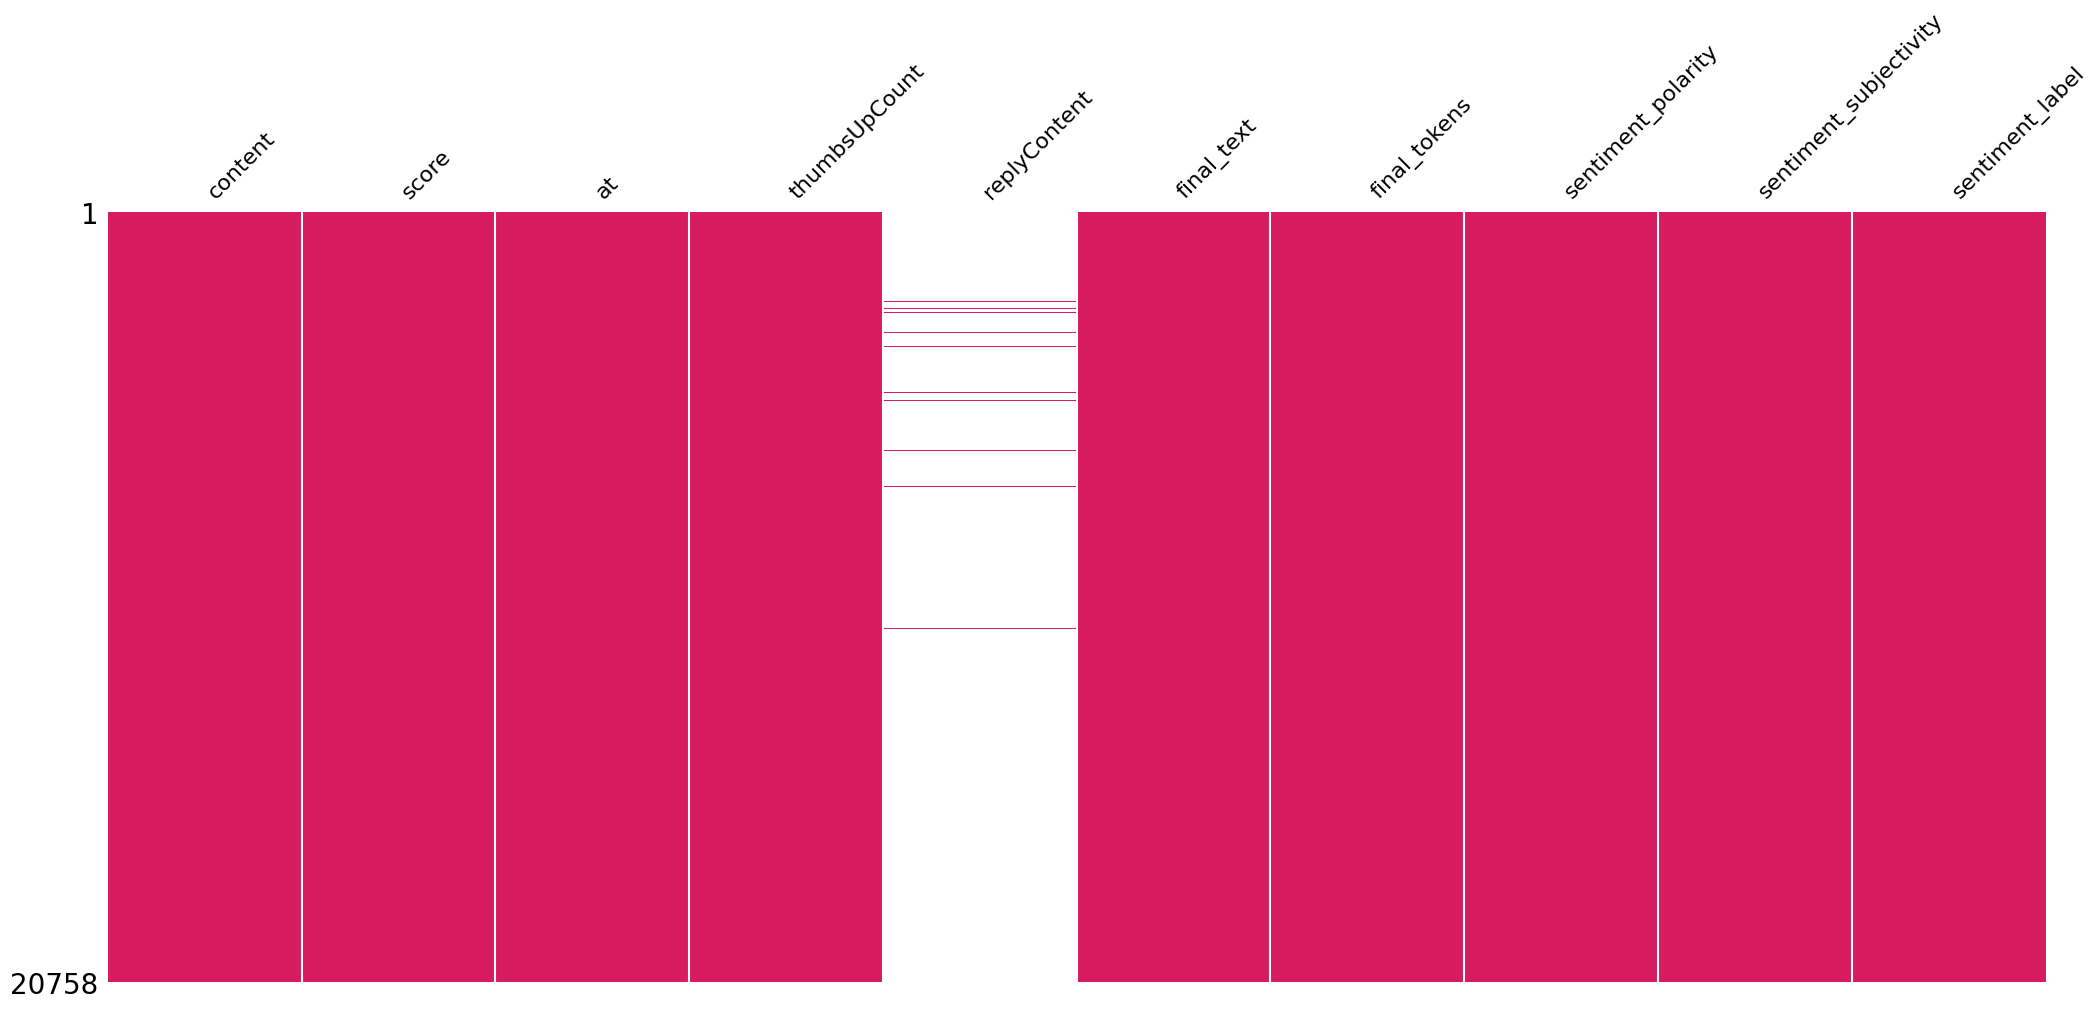

In [35]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(
    df_notion_clean,
    sparkline=False,
    color=(0.847, 0.106, 0.376)  # #D81B60
)

plt.show()

In [41]:
df_notion_clean['at'] = pd.to_datetime(df_notion_clean['at'], errors='coerce')

df_selected = df_notion_clean.assign(
    year=df_notion_clean['at'].dt.year
)[
    ['content', 'final_text', 'score', 'sentiment_label', 'at', 'year']
]

df_selected.head()

,content,final_text,score,sentiment_label,at,year
0,"had a payment issue, the SAV solved it quickly.",payment issu solv quickli,5,neutral,2026-04-29 16:35:03,2026
1,"Using Notion on a high-end phone, but it keeps getting laggier after updates. Table selection is difficult, especially for full rows or columns, and copying email addresses adds a “mailto:” prefix. Basic features feel broken, making the app frustrating to use. Moving away because of this. I'm going back to google ecosystem.",use notion highend phone keep get laggier updat tabl select difficult especi full row column copi email address add basic featur feel broken make app frustrat use move away im go back googl ecosystem,1,negative,2026-04-29 14:15:07,2026
2,"I loved this app, but my documents keep going missing",love app document keep go miss,3,positive,2026-04-29 10:38:49,2026
3,powerful (All in 1). but new ke liye itna jada hard hai use karna very bad ui ux 🤬,power new ke hard hai use bad ui ux,1,negative,2026-04-29 09:22:59,2026
4,"Very bad mobile experience. Everything is so slow, Its so hard to actually save anything on mobile.",bad mobil experi everyth slow hard actual save anyth mobil,1,negative,2026-04-28 20:29:03,2026


### **Scatter Plot: Polarity vs Subjectivity**

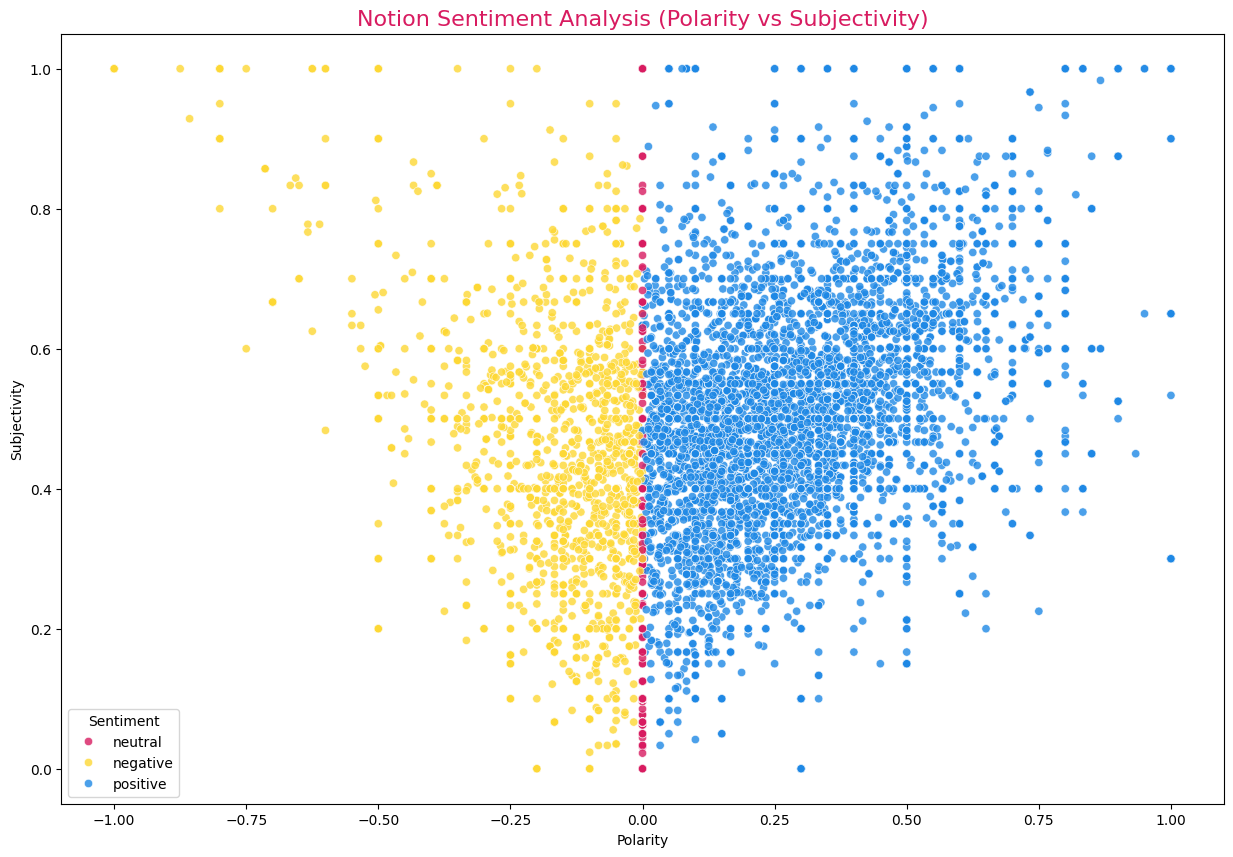

In [43]:
plt.figure(figsize=(15, 10))

sns.scatterplot(
    data=df_notion_clean,
    x='sentiment_polarity',
    y='sentiment_subjectivity',
    hue='sentiment_label',
    palette=['#D81B60', '#FDD835', '#1E88E5'],
    edgecolor='white',
    alpha=0.8
)

plt.title('Notion Sentiment Analysis (Polarity vs Subjectivity)', fontsize=16, color='#D81B60')
plt.xlabel('Polarity')
plt.ylabel('Subjectivity')
plt.legend(title='Sentiment')
plt.show()

### **Most Frequent Words**

In [46]:
from nltk.probability import FreqDist
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

nltk.download('punkt', quiet=True)

def freq_words(x, terms=30):
    all_words = ' '.join([str(text) for text in x if isinstance(text, str)])
    all_words = all_words.split()

    fdist = FreqDist(all_words)

    words_df = pd.DataFrame({
        'word': list(fdist.keys()),
        'count': list(fdist.values())
    })

    d = words_df.nlargest(columns='count', n=terms).reset_index(drop=True)

    cmap = LinearSegmentedColormap.from_list(
        "notion_gradient",
        ['#D81B60', '#FDD835', '#1E88E5']
    )

    colors = [cmap(i / len(d)) for i in range(len(d))]

    plt.figure(figsize=(20, 6))

    ax = sns.barplot(
        data=d,
        x='word',
        y='count',
        palette=colors
    )

    ax.set_ylabel('Count')
    ax.set_xlabel('Words')

    plt.xticks(rotation=45, ha='right')

    plt.title(
        f'Top {terms} Most Frequent Words',
        fontsize=14,
        color='#D81B60'
    )

    plt.tight_layout()
    plt.show()

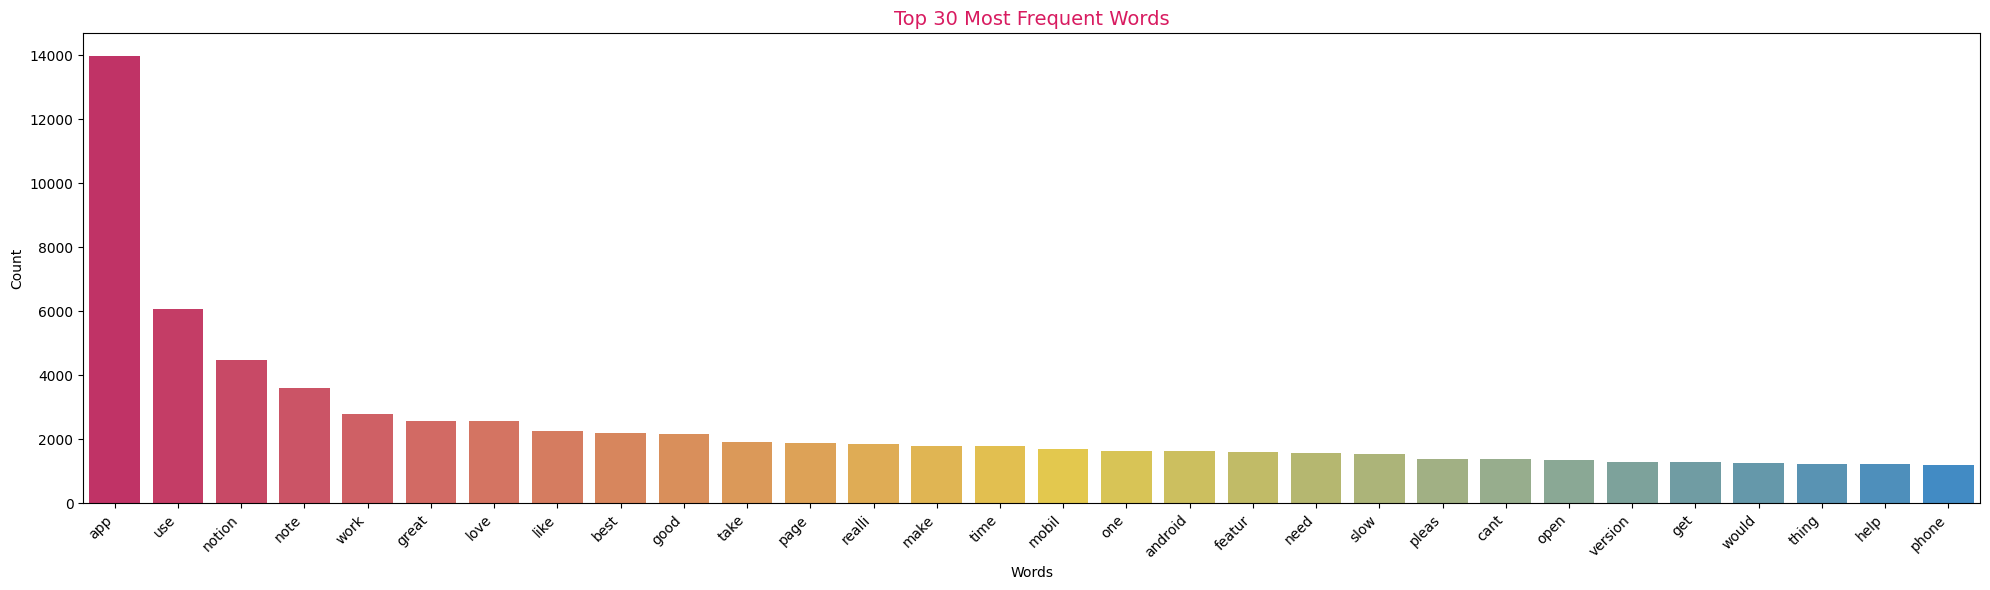

In [47]:
freq_words(df_notion_clean['final_text'])

### **Word Cloud (All Reviews)**

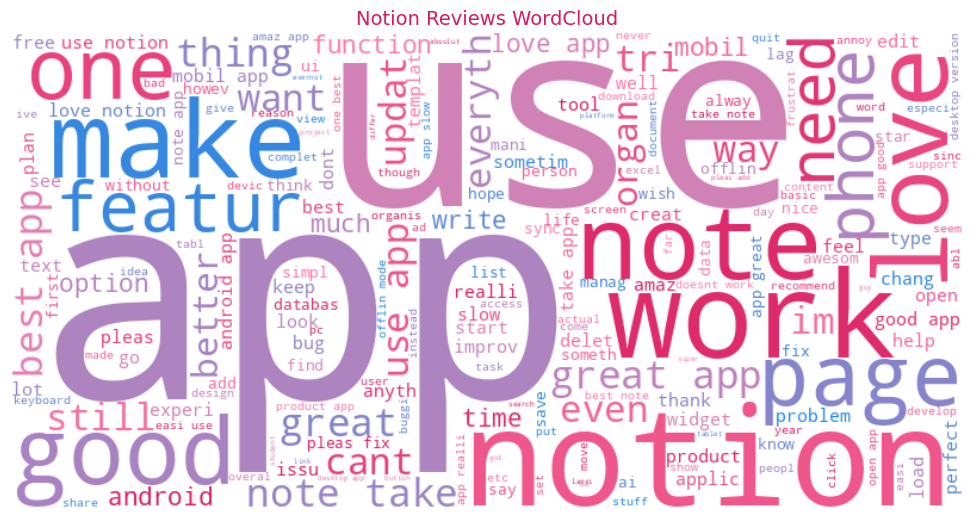

In [52]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

all_text = ' '.join(df_notion_clean['final_text'].dropna().astype(str))

pink_blue = LinearSegmentedColormap.from_list(
    "pink_blue",
    ['#D81B60', '#FF80AB', '#1E88E5']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap=pink_blue
).generate(all_text)

plt.figure(figsize=(10, 5), facecolor='white')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title('Notion Reviews WordCloud', color='#D81B60', fontsize=14)

plt.tight_layout(pad=0)
plt.show()

### **Word Cloud (Positive vs Negative)**

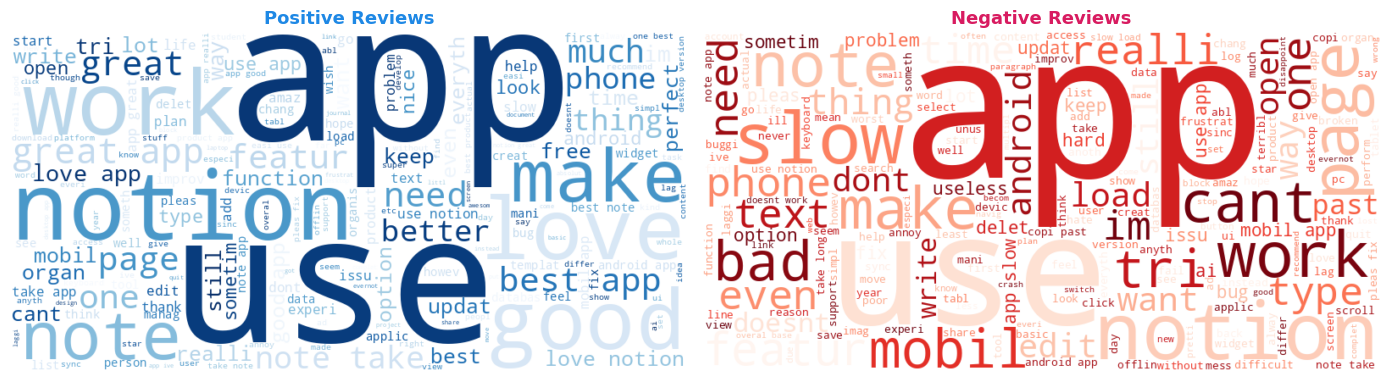

In [55]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

positive_reviews = df_notion_clean[
    df_notion_clean['sentiment_label'] == 'positive'
]['final_text'].astype(str)

negative_reviews = df_notion_clean[
    df_notion_clean['sentiment_label'] == 'negative'
]['final_text'].astype(str)

pink_blue = LinearSegmentedColormap.from_list(
    "pink_blue",
    ['#D81B60', '#FF80AB', '#1E88E5']
)

positive_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Blues'
).generate(' '.join(positive_reviews))

negative_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(' '.join(negative_reviews))

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.title('Positive Reviews', color='#1E88E5', fontsize=13, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.title('Negative Reviews', color='#D81B60', fontsize=13, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

### **Review Count by Year**

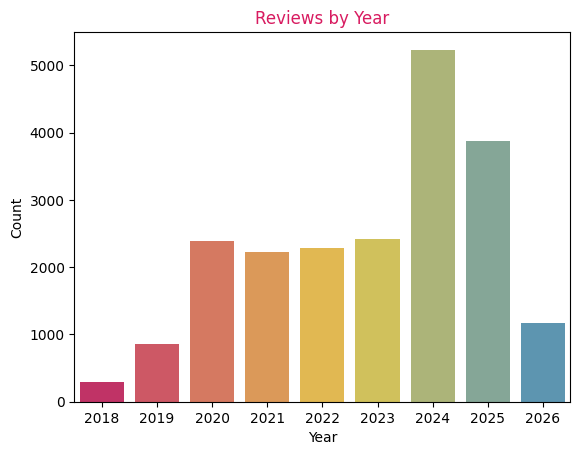

In [67]:
df_notion_clean['year'] = pd.to_datetime(df_notion_clean['at']).dt.year
reviews = df_notion_clean.groupby('year')['content'].count()

cmap = LinearSegmentedColormap.from_list(
    "notion",
    ['#D81B60', '#FDD835', '#1E88E5']
)

colors = [cmap(i/len(reviews)) for i in range(len(reviews))]

sns.barplot(
    x=reviews.index,
    y=reviews.values,
    palette=colors
)

plt.title('Reviews by Year', color='#D81B60')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

### **Distribution of Ratings**

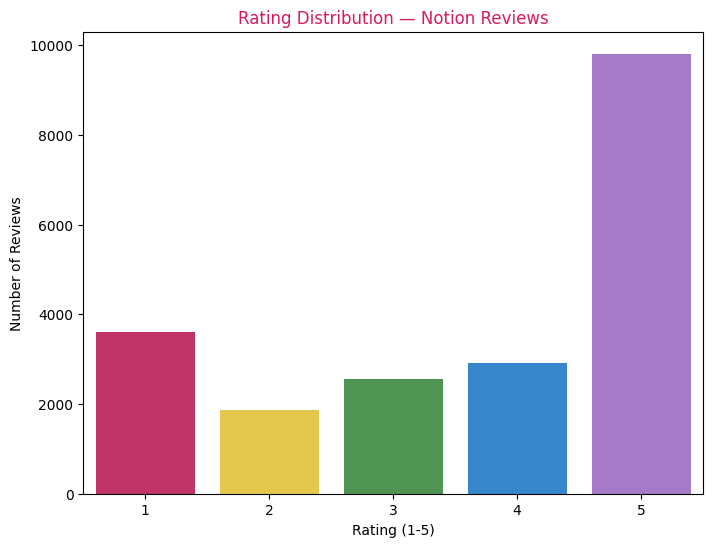

In [70]:
plt.figure(figsize=(8, 6))

sns.countplot(
    x='score',
    data=df_gopay_clean,
    palette=['#D81B60', '#FDD835', '#43A047', '#1E88E5', "#A66DD4"]
)

plt.title('Rating Distribution — Notion Reviews', color='#D81B60')
plt.xlabel('Rating (1-5)')
plt.ylabel('Number of Reviews')

plt.show()

### **Sentiment Trend Over Time (by Year)**

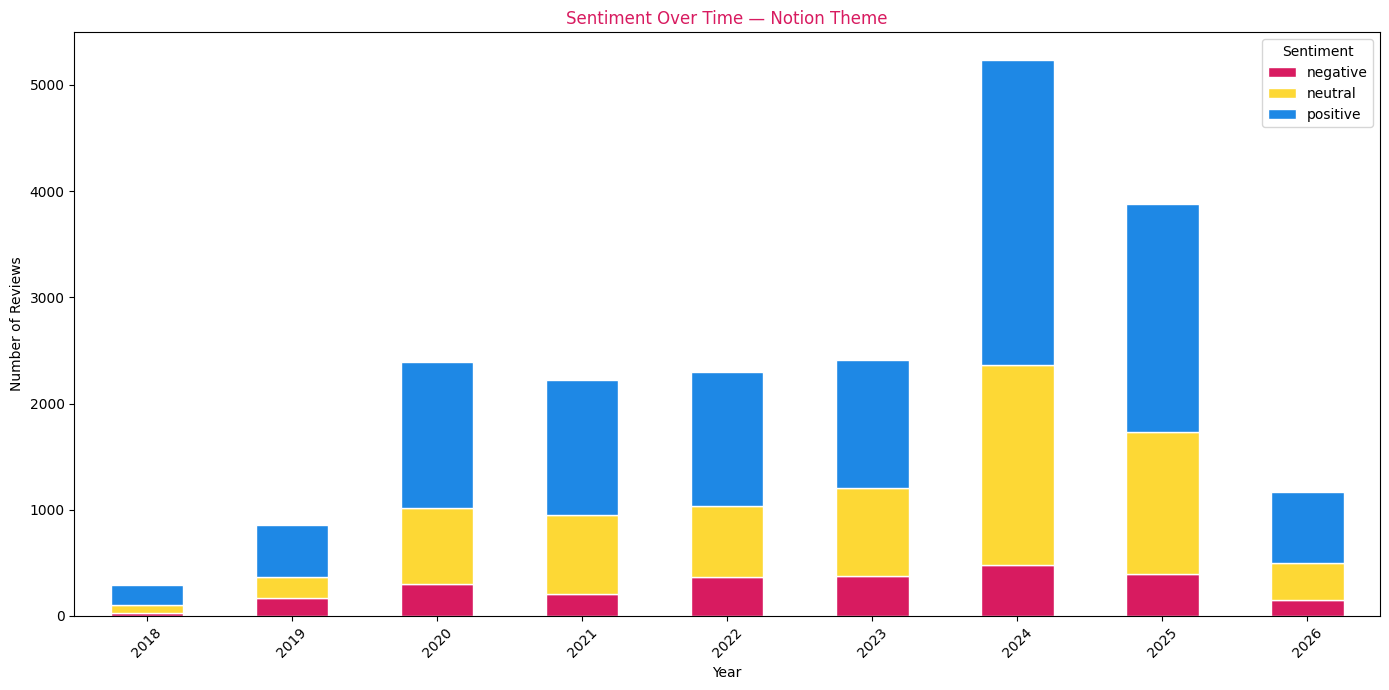

In [72]:
sentiment_over_time = df_notion_clean.groupby(['year', 'sentiment_label']).size().unstack(fill_value=0)

order = ['negative', 'neutral', 'positive']
for col in order:
    if col not in sentiment_over_time.columns:
        sentiment_over_time[col] = 0

sentiment_over_time = sentiment_over_time[order]

stack_colors = ['#D81B60', '#FDD835', '#1E88E5']

fig, ax = plt.subplots(figsize=(14, 7))

sentiment_over_time.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=stack_colors,
    edgecolor='white'
)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.set_title('Sentiment Over Time — Notion Theme', color='#D81B60')
ax.legend(title='Sentiment')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Save Dataset**

---



In [77]:
output_path = '/content/drive/MyDrive/Tugas Individu/Dataset/notion_reviews_sentiment.csv'

df_notion_clean.to_csv(output_path, index=False)

print(f'Dataset saved: {output_path}')
print(f'Shape: {df_notion_clean.shape}')
df_notion_clean.head()

Dataset saved: /content/drive/MyDrive/Tugas Individu/Dataset/notion_reviews_sentiment.csv
Shape: (20758, 11)


,content,score,at,thumbsUpCount,replyContent,final_text,final_tokens,sentiment_polarity,sentiment_subjectivity,sentiment_label,year
0,"had a payment issue, the SAV solved it quickly.",5,2026-04-29 16:35:03,0,NaN,payment issu solv quickli,"['payment', 'issu', 'solv', 'quickli']",0.000000,0.000000,neutral,2026
1,"Using Notion on a high-end phone, but it keeps getting laggier after updates. Table selection is difficult, especially for full rows or columns, and copying email addresses adds a “mailto:” prefix. Basic features feel broken, making the app frustrating to use. Moving away because of this. I'm going back to google ecosystem.",1,2026-04-29 14:15:07,0,NaN,use notion highend phone keep get laggier updat tabl select difficult especi full row column copi email address add basic featur feel broken make app frustrat use move away im go back googl ecosystem,"['use', 'notion', 'highend', 'phone', 'keep', 'get', 'laggier', 'updat', 'tabl', 'select', 'difficult', 'especi', 'full', 'row', 'column', 'copi', 'email', 'address', 'add', 'basic', 'featur', 'feel', 'broken', 'make', 'app', 'frustrat', 'use', 'move', 'away', 'im', 'go', 'back', 'googl', 'ecosystem']",-0.110000,0.415000,negative,2026
2,"I loved this app, but my documents keep going missing",3,2026-04-29 10:38:49,0,NaN,love app document keep go miss,"['love', 'app', 'document', 'keep', 'go', 'miss']",0.500000,0.600000,positive,2026
3,powerful (All in 1). but new ke liye itna jada hard hai use karna very bad ui ux 🤬,1,2026-04-29 09:22:59,0,NaN,power new ke hard hai use bad ui ux,"['power', 'new', 'ke', 'hard', 'hai', 'use', 'bad', 'ui', 'ux']",-0.285101,0.554293,negative,2026
4,"Very bad mobile experience. Everything is so slow, Its so hard to actually save anything on mobile.",1,2026-04-28 20:29:03,0,NaN,bad mobil experi everyth slow hard actual save anyth mobil,"['bad', 'mobil', 'experi', 'everyth', 'slow', 'hard', 'actual', 'save', 'anyth', 'mobil']",-0.322917,0.427083,negative,2026
